In [143]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) #Adjust the configuration of the plots we will create

#Read in the data
df = pd.read_csv(r'movies.csv')

In [144]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [145]:
df.columns

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime'],
      dtype='object')

In [146]:
#Reorganize columns
df = df[['budget','company','country','director','genre','gross','name', 'rating',
    'released','runtime','score','star', 'votes','writer','year']]

In [147]:
#Find the percentage of missing values in each columns.
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col,pct_missing))

budget - 0.2831246739697444%
company - 0.002217005738132499%
country - 0.0003912363067292645%
director - 0.0%
genre - 0.0%
gross - 0.02464788732394366%
name - 0.0%
rating - 0.010041731872717789%
released - 0.0002608242044861763%
runtime - 0.0005216484089723526%
score - 0.0003912363067292645%
star - 0.00013041210224308815%
votes - 0.0003912363067292645%
writer - 0.0003912363067292645%
year - 0.0%


In [148]:
df.dtypes

budget      float64
company      object
country      object
director     object
genre        object
gross       float64
name         object
rating       object
released     object
runtime     float64
score       float64
star         object
votes       float64
writer       object
year          int64
dtype: object

In [149]:
#Convert float64 to int64 and replace missing values with median of numeric columns .
df['budget'] = df['budget'].fillna(df['budget'].median())

df['gross'] = df['gross'].fillna(df['gross'].median())

df['runtime'] = df['runtime'].fillna(df['runtime'].median())
df['runtime'] = df['runtime'].astype('int64')

df['votes'] = df['votes'].fillna(df['votes'].median())
df['votes'] = df['votes'].astype('int64')

df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year
0,19000000.0,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772.0,The Shining,R,"June 13, 1980 (United States)",146,8.4,Jack Nicholson,927000,Stephen King,1980
1,4500000.0,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106.0,The Blue Lagoon,R,"July 2, 1980 (United States)",104,5.8,Brooke Shields,65000,Henry De Vere Stacpoole,1980
2,18000000.0,Lucasfilm,United States,Irvin Kershner,Action,538375067.0,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124,8.7,Mark Hamill,1200000,Leigh Brackett,1980
3,3500000.0,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539.0,Airplane!,PG,"July 2, 1980 (United States)",88,7.7,Robert Hays,221000,Jim Abrahams,1980
4,6000000.0,Orion Pictures,United States,Harold Ramis,Comedy,39846344.0,Caddyshack,R,"July 25, 1980 (United States)",98,7.3,Chevy Chase,108000,Brian Doyle-Murray,1980


In [150]:
# Convert data to string for extraction
df['released'] = df['released'].astype('str')

In [151]:
# Create a new year column as current 'year' mismatch with year in 'released'
df['year_correct'] = df['released']

In [152]:
for index in df.index:
    if df.loc[index,'year_correct'] == 'nan': #Handle 'nan' values of column 'released'.
        df.loc[index,'year_correct'] = df.loc[index,'year']
    else:
        #Find the position and extract the 'year' (4-digit) in each rows of column 'year_correct'.
        span = re.search(r'(\d{4})', df.loc[index,'year_correct']).span()
        df.loc[index,'year_correct'] = df.loc[index,'year_correct'][int(span[0]):int(span[1])]
        
df['year_correct'] = df['year_correct'].astype('int64')
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct
0,19000000.0,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772.0,The Shining,R,"June 13, 1980 (United States)",146,8.4,Jack Nicholson,927000,Stephen King,1980,1980
1,4500000.0,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106.0,The Blue Lagoon,R,"July 2, 1980 (United States)",104,5.8,Brooke Shields,65000,Henry De Vere Stacpoole,1980,1980
2,18000000.0,Lucasfilm,United States,Irvin Kershner,Action,538375067.0,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124,8.7,Mark Hamill,1200000,Leigh Brackett,1980,1980
3,3500000.0,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539.0,Airplane!,PG,"July 2, 1980 (United States)",88,7.7,Robert Hays,221000,Jim Abrahams,1980,1980
4,6000000.0,Orion Pictures,United States,Harold Ramis,Comedy,39846344.0,Caddyshack,R,"July 25, 1980 (United States)",98,7.3,Chevy Chase,108000,Brian Doyle-Murray,1980,1980


In [153]:
df['year_correct'].isnull().sum()

np.int64(0)

In [154]:
# Extract month from 'released' column
df['month'] = df['released']

In [155]:
for index in df.index:
    df.loc[index,'month'] = df.loc[index,'month'].split()[0]

df["month"] = df["month"].map(
    {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 
     'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
)
df['month'] = df['month'].astype('Int64') # Int64 instead of int64 because Int64 allows null value
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct,month
0,19000000.0,Warner Bros.,United Kingdom,Stanley Kubrick,Drama,46998772.0,The Shining,R,"June 13, 1980 (United States)",146,8.4,Jack Nicholson,927000,Stephen King,1980,1980,6
1,4500000.0,Columbia Pictures,United States,Randal Kleiser,Adventure,58853106.0,The Blue Lagoon,R,"July 2, 1980 (United States)",104,5.8,Brooke Shields,65000,Henry De Vere Stacpoole,1980,1980,7
2,18000000.0,Lucasfilm,United States,Irvin Kershner,Action,538375067.0,Star Wars: Episode V - The Empire Strikes Back,PG,"June 20, 1980 (United States)",124,8.7,Mark Hamill,1200000,Leigh Brackett,1980,1980,6
3,3500000.0,Paramount Pictures,United States,Jim Abrahams,Comedy,83453539.0,Airplane!,PG,"July 2, 1980 (United States)",88,7.7,Robert Hays,221000,Jim Abrahams,1980,1980,7
4,6000000.0,Orion Pictures,United States,Harold Ramis,Comedy,39846344.0,Caddyshack,R,"July 25, 1980 (United States)",98,7.3,Chevy Chase,108000,Brian Doyle-Murray,1980,1980,7


In [156]:
# Setup float display format
pd.set_option('display.float_format', '{:,.0f}'.format)

In [157]:
# df.style.format(thousands=',')
# pd.set_option("styler.format.thousands", ",")

In [158]:
df.sort_values(by = ['gross'], inplace = True, ascending = False)

In [159]:
df = df.reset_index()
df = df.drop(['index'],axis=1)
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct,month
0,"237,000,000",Twentieth Century Fox,United States,James Cameron,Action,"2,847,246,203",Avatar,PG-13,"December 18, 2009 (United States)",162,8,Sam Worthington,1100000,James Cameron,2009,2009,12
1,"356,000,000",Marvel Studios,United States,Anthony Russo,Action,"2,797,501,328",Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181,8,Robert Downey Jr.,903000,Christopher Markus,2019,2019,4
2,"200,000,000",Twentieth Century Fox,United States,James Cameron,Drama,"2,201,647,264",Titanic,PG-13,"December 19, 1997 (United States)",194,8,Leonardo DiCaprio,1100000,James Cameron,1997,1997,12
3,"245,000,000",Lucasfilm,United States,J.J. Abrams,Action,"2,069,521,700",Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138,8,Daisy Ridley,876000,Lawrence Kasdan,2015,2015,12
4,"321,000,000",Marvel Studios,United States,Anthony Russo,Action,"2,048,359,754",Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149,8,Robert Downey Jr.,897000,Christopher Markus,2018,2018,4


In [160]:
# pd.set_option('display.max_rows', None)

In [161]:
df.dtypes

budget          float64
company          object
country          object
director         object
genre            object
gross           float64
name             object
rating           object
released         object
runtime           int64
score           float64
star             object
votes             int64
writer           object
year              int64
year_correct      int64
month             Int64
dtype: object

In [162]:
df = df.drop_duplicates()

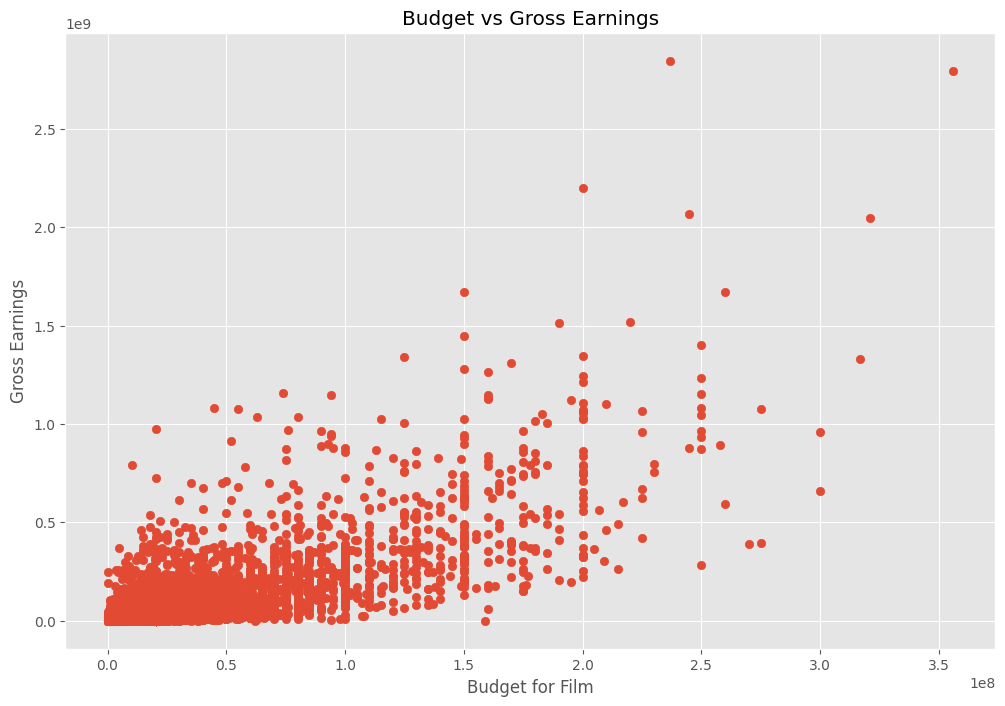

In [163]:
#Plot Budget vs Gross scatter plot

plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.ylabel('Gross Earnings')
plt.xlabel('Budget for Film')
plt.show()

In [164]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct,month
0,"237,000,000",Twentieth Century Fox,United States,James Cameron,Action,"2,847,246,203",Avatar,PG-13,"December 18, 2009 (United States)",162,8,Sam Worthington,1100000,James Cameron,2009,2009,12
1,"356,000,000",Marvel Studios,United States,Anthony Russo,Action,"2,797,501,328",Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181,8,Robert Downey Jr.,903000,Christopher Markus,2019,2019,4
2,"200,000,000",Twentieth Century Fox,United States,James Cameron,Drama,"2,201,647,264",Titanic,PG-13,"December 19, 1997 (United States)",194,8,Leonardo DiCaprio,1100000,James Cameron,1997,1997,12
3,"245,000,000",Lucasfilm,United States,J.J. Abrams,Action,"2,069,521,700",Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138,8,Daisy Ridley,876000,Lawrence Kasdan,2015,2015,12
4,"321,000,000",Marvel Studios,United States,Anthony Russo,Action,"2,048,359,754",Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149,8,Robert Downey Jr.,897000,Christopher Markus,2018,2018,4


<Axes: xlabel='budget', ylabel='gross'>

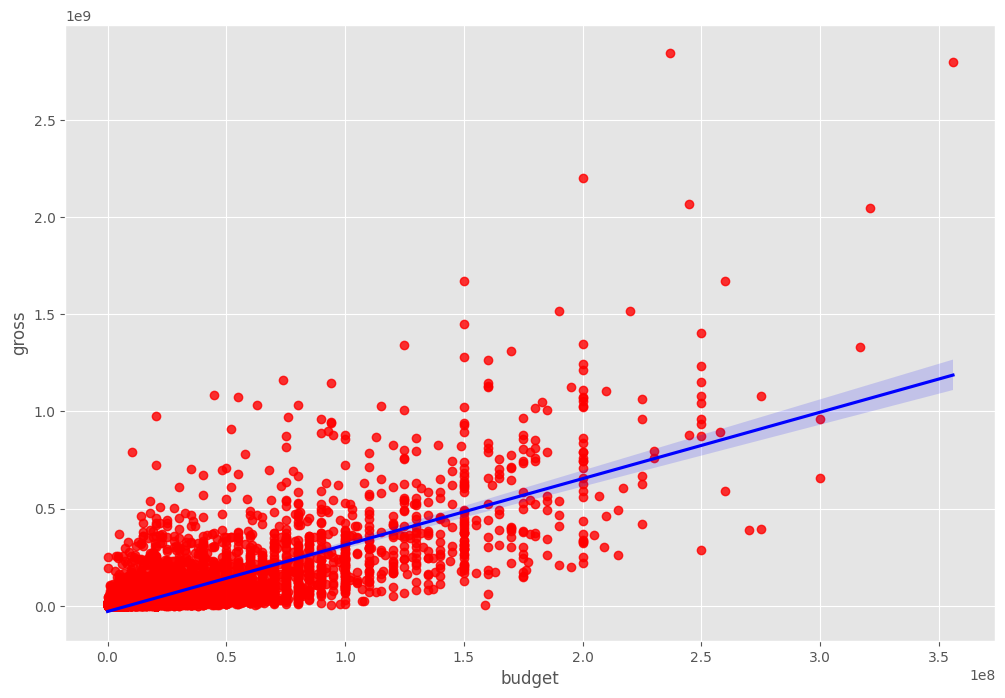

In [165]:
#Add trend line to scatter plot
sns.regplot(x = 'budget', y = 'gross', data = df, scatter_kws = {"color": "red"} , line_kws={"color":"blue"})

In [166]:
pd.reset_option('display.float_format')

In [167]:
#Find correlation of numeric columns

df.select_dtypes(include=['int64', 'float64', 'Int64']).corr(method = 'pearson') #pearson (default), kendall, spearman

,budget,gross,runtime,score,votes,year,year_correct,month
budget,1.000000,0.745881,0.273371,0.061979,0.460968,0.291690,0.283993,0.060326
gross,0.745881,1.000000,0.244380,0.185583,0.632120,0.259504,0.252598,0.057731
runtime,0.273371,0.244380,1.000000,0.399449,0.309151,0.120662,0.120490,0.069534
score,0.061979,0.185583,0.399449,1.000000,0.409182,0.097995,0.105821,0.054062
votes,0.460968,0.632120,0.309151,0.409182,1.000000,0.222573,0.218059,0.058458
year,0.291690,0.259504,0.120662,0.097995,0.222573,1.000000,0.997416,-0.004779
year_correct,0.283993,0.252598,0.120490,0.105821,0.218059,0.997416,1.000000,-0.017764
month,0.060326,0.057731,0.069534,0.054062,0.058458,-0.004779,-0.017764,1.000000


In [168]:
## High correlation between budget and gross

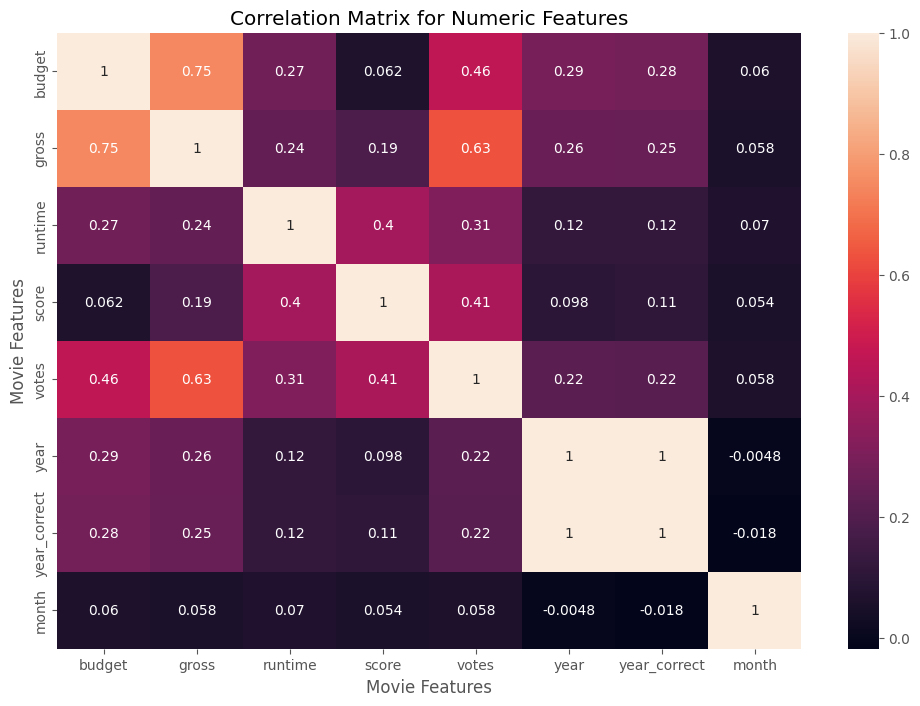

In [169]:
#Use heatmap to visualize correlation matrix

correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr(method = 'pearson') 
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [170]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct,month
0,237000000.0,Twentieth Century Fox,United States,James Cameron,Action,2.847246e+09,Avatar,PG-13,"December 18, 2009 (United States)",162,7.8,Sam Worthington,1100000,James Cameron,2009,2009,12
1,356000000.0,Marvel Studios,United States,Anthony Russo,Action,2.797501e+09,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181,8.4,Robert Downey Jr.,903000,Christopher Markus,2019,2019,4
2,200000000.0,Twentieth Century Fox,United States,James Cameron,Drama,2.201647e+09,Titanic,PG-13,"December 19, 1997 (United States)",194,7.8,Leonardo DiCaprio,1100000,James Cameron,1997,1997,12
3,245000000.0,Lucasfilm,United States,J.J. Abrams,Action,2.069522e+09,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138,7.8,Daisy Ridley,876000,Lawrence Kasdan,2015,2015,12
4,321000000.0,Marvel Studios,United States,Anthony Russo,Action,2.048360e+09,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149,8.4,Robert Downey Jr.,897000,Christopher Markus,2018,2018,4


In [171]:
df.dtypes

budget          float64
company          object
country          object
director         object
genre            object
gross           float64
name             object
rating           object
released         object
runtime           int64
score           float64
star             object
votes             int64
writer           object
year              int64
year_correct      int64
month             Int64
dtype: object

In [172]:
#Convert categorical columns into numeric for calculating correlation
df_numerized = df.copy()

for col_name in df_numerized.columns:
    if (df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
        
df_numerized.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct,month
0,237000000.0,2253,55,1155,0,2.847246e+09,533,5,696,162,7.8,2334,1100000,1778,2009,2009,12
1,356000000.0,1606,55,162,0,2.797501e+09,535,5,183,181,8.4,2241,903000,743,2019,2019,4
2,200000000.0,2253,55,1155,6,2.201647e+09,6896,5,704,194,7.8,1595,1100000,1778,1997,1997,12
3,245000000.0,1540,55,1125,0,2.069522e+09,5144,5,698,138,7.8,524,876000,2550,2015,2015,12
4,321000000.0,1606,55,162,0,2.048360e+09,536,5,192,149,8.4,2241,897000,743,2018,2018,4


In [173]:
df.head()

,budget,company,country,director,genre,gross,name,rating,released,runtime,score,star,votes,writer,year,year_correct,month
0,237000000.0,Twentieth Century Fox,United States,James Cameron,Action,2.847246e+09,Avatar,PG-13,"December 18, 2009 (United States)",162,7.8,Sam Worthington,1100000,James Cameron,2009,2009,12
1,356000000.0,Marvel Studios,United States,Anthony Russo,Action,2.797501e+09,Avengers: Endgame,PG-13,"April 26, 2019 (United States)",181,8.4,Robert Downey Jr.,903000,Christopher Markus,2019,2019,4
2,200000000.0,Twentieth Century Fox,United States,James Cameron,Drama,2.201647e+09,Titanic,PG-13,"December 19, 1997 (United States)",194,7.8,Leonardo DiCaprio,1100000,James Cameron,1997,1997,12
3,245000000.0,Lucasfilm,United States,J.J. Abrams,Action,2.069522e+09,Star Wars: Episode VII - The Force Awakens,PG-13,"December 18, 2015 (United States)",138,7.8,Daisy Ridley,876000,Lawrence Kasdan,2015,2015,12
4,321000000.0,Marvel Studios,United States,Anthony Russo,Action,2.048360e+09,Avengers: Infinity War,PG-13,"April 27, 2018 (United States)",149,8.4,Robert Downey Jr.,897000,Christopher Markus,2018,2018,4


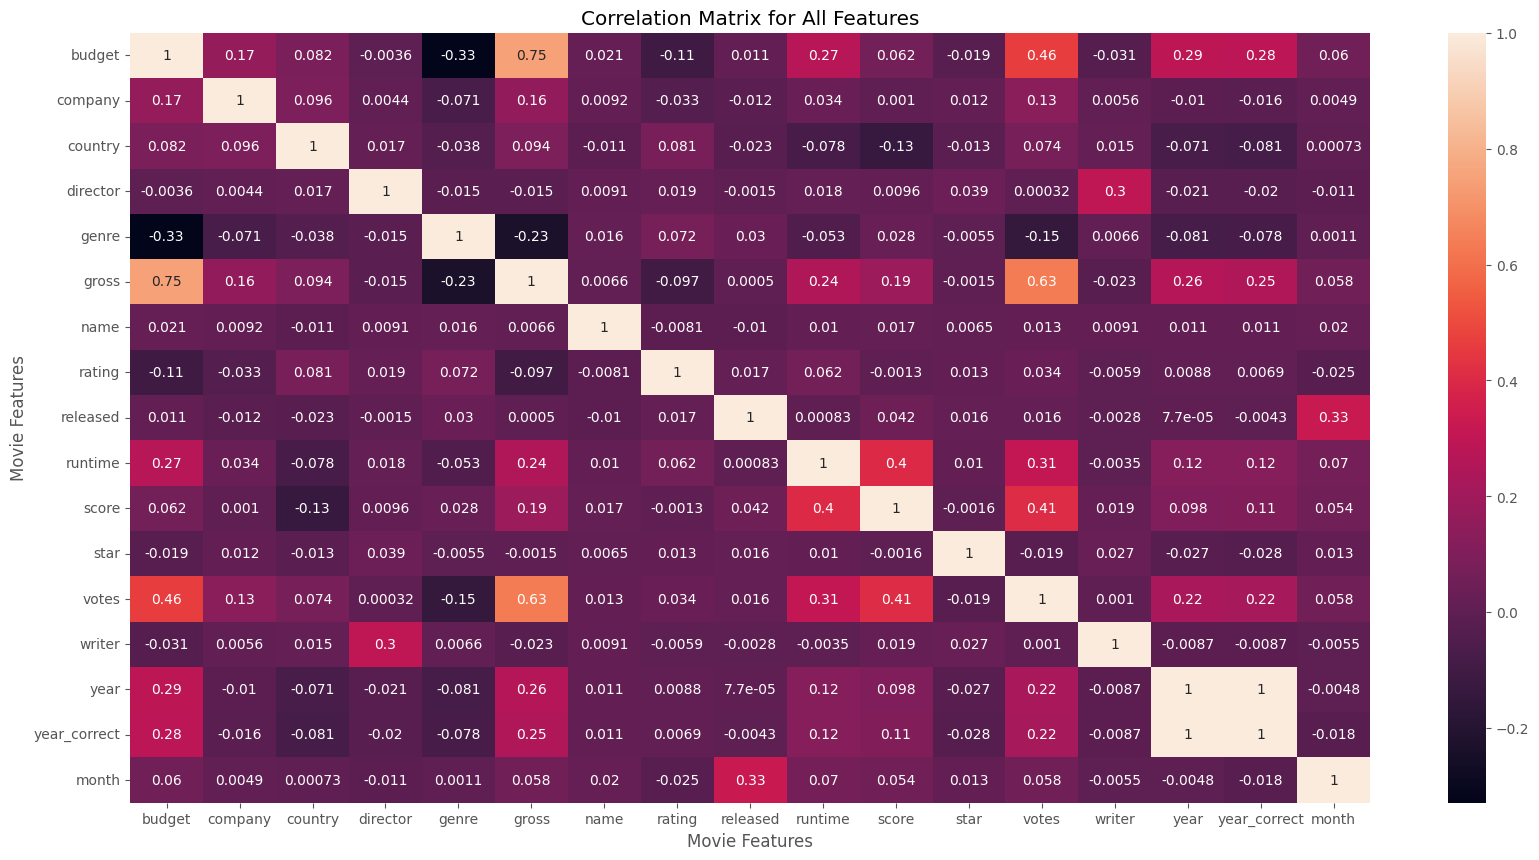

In [174]:
#Plot correlation matrix heatmap

correlation_matrix = df_numerized.corr(method = 'pearson') 
plt.figure(figsize=(20,10))
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for All Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [175]:
#Reshape correlation data
correlation_mat = df_numerized.corr()
corr_pairs = correlation_mat.unstack()
corr_pairs

budget  budget          1.000000
        company         0.167250
        country         0.082334
        director       -0.003584
        genre          -0.328484
                          ...   
month   votes           0.058458
        writer         -0.005488
        year           -0.004779
        year_correct   -0.017764
        month           1.000000
Length: 289, dtype: float64

In [176]:
#Sort and filter to identify highly correlated variables
sorted_pairs = corr_pairs.sort_values()
high_corr = sorted_pairs[(sorted_pairs > 0.5) & (sorted_pairs < 0.9)]
high_corr

votes   gross     0.632120
gross   votes     0.632120
        budget    0.745881
budget  gross     0.745881
dtype: float64

In [177]:
#Votes and budget have the highest correlation to gross earnings.